In [7]:
from sklearn.datasets import load_wine
import numpy as np
data = load_wine()
features = data['data']
labels = data['target']
features.shape

(178, 13)

In [8]:
# It's also possible to manually compute eigenvectors and eigenvalues
subset_idx = 3
cov = np.cov(features)[:subset_idx, :subset_idx]
eig_vals, eig_vecs = np.linalg.eig(cov)
print("Eigenvalues: \n", eig_vals)
print("Eigenvectors: \n", eig_vecs)

Eigenvalues: 
 [2.75887696e+05 5.66833522e+01 1.34732230e+00]
Eigenvectors: 
 [[-0.55810925 -0.78959847  0.25504573]
 [-0.55046096  0.12232505 -0.82585066]
 [-0.62089193  0.60130761  0.50291387]]


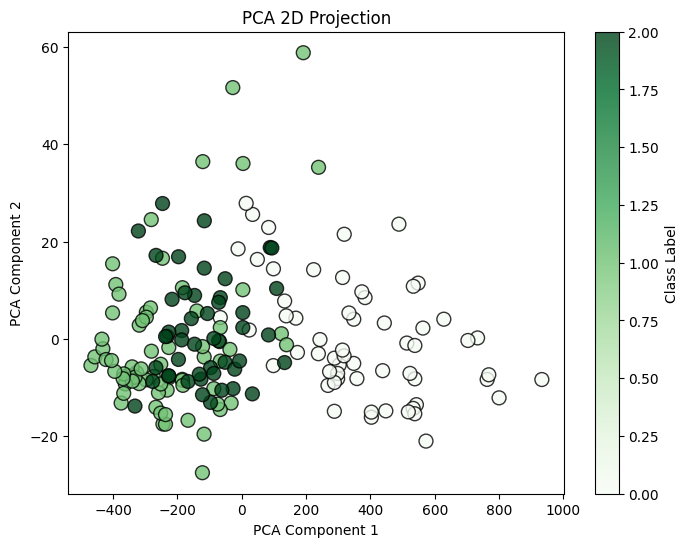

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_2d = pca.fit_transform(features)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, cmap="Greens", edgecolors="black", s=100, alpha=0.8)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA 2D Projection")
plt.colorbar(label="Class Label")  # 加上顏色對應的類別
plt.show()


In [10]:
print("Eigenvalues: \n", pca.explained_variance_ratio_)
print("Eigenvectors: \n", pca.components_)

Eigenvalues: 
 [0.99809123 0.00173592]
Eigenvectors: 
 [[ 1.65926472e-03 -6.81015556e-04  1.94905742e-04 -4.67130058e-03
   1.78680075e-02  9.89829680e-04  1.56728830e-03 -1.23086662e-04
   6.00607792e-04  2.32714319e-03  1.71380037e-04  7.04931645e-04
   9.99822937e-01]
 [ 1.20340617e-03  2.15498184e-03  4.59369254e-03  2.64503930e-02
   9.99344186e-01  8.77962152e-04 -5.18507284e-05 -1.35447892e-03
   5.00440040e-03  1.51003530e-02 -7.62673115e-04 -3.49536431e-03
  -1.77738095e-02]]


In [13]:
pca = PCA(n_components=3)
pca_3d = pca.fit_transform(features)

import plotly.express as px
import pandas as pd

# 轉換 PCA
pca = PCA(n_components=3)
pca_3d = pca.fit_transform(features)

# 創建 DataFrame 以供 Plotly 使用
df = pd.DataFrame({"PCA1": pca_3d[:, 0], "PCA2": pca_3d[:, 1], "PCA3": pca_3d[:, 2], "Label": labels})

# 繪製 3D 互動式散點圖
fig = px.scatter_3d(df, x="PCA1", y="PCA2", z="PCA3", color=df["Label"].astype(str),
                    title="PCA 3D Projection", color_continuous_scale="Greens")

fig.show()


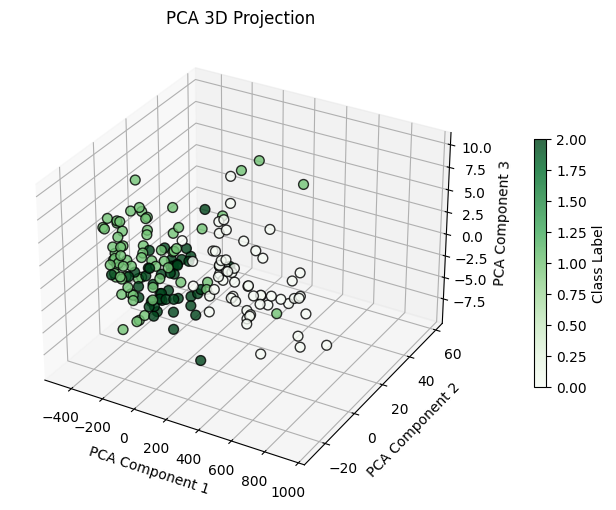

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 假設 features 是原始數據，先進行 PCA 降維到 3D
pca = PCA(n_components=3)
pca_3d = pca.fit_transform(features)

# 繪製 3D 散點圖
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], 
                     c=labels, cmap="Greens", edgecolors="black", s=50, alpha=0.8)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("PCA 3D Projection")

# 加上顏色標籤
legend1 = plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.1)
legend1.set_label("Class Label")

plt.show()
